# Multiple Linear Regression – Multi-Channel Marketing Analysis

### Objective
Build a multivariate OLS regression model to evaluate the impact of TV, Radio, and Social Media advertising budgets on total Sales, check for multicollinearity, and justify budget allocations.

### Step 1: Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Load dataset
df = pd.read_csv('c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv')

# Display basic information
print(df.head())
print(df.info())


       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB
None


In [2]:
# Inspect missing values
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


### Step 2: Data Preprocessing
The `TV` variable is categorical ("Low", "Medium", "High"). To accurately check for multicollinearity and include it in our regression model alongside the continuous `Radio` and `Social Media` variables, we must apply ordinal encoding to translate the tiers into numerical weights (1, 2, 3). We will also drop any missing values to ensure model stability.

In [4]:
# Ordinal encode the categorical TV column
df['TV_encoded'] = df['TV'].map({'Low': 1, 'Medium': 2, 'High': 3})

# Define our independent variables (Features) and dependent variable (Target)
features = ['TV_encoded', 'Radio', 'Social Media']
X = df[features]
y = df['Sales']

print(X.head())
print(y.head())

   TV_encoded      Radio  Social Media
0           1   3.518070      2.293790
1           1   7.756876      2.572287
2           3  20.348988      1.227180
3           2  20.108487      2.728374
4           3  31.653200      7.776978
0     55.261284
1     67.574904
2    272.250108
3    195.102176
4    273.960377
Name: Sales, dtype: float64


### Step 3: Check for Multicollinearity
Before building the model, we must ensure our independent variables are not highly correlated with each other. We will use a Pearson correlation matrix and calculate the Variance Inflation Factor (VIF). A VIF threshold > 5 typically indicates problematic multicollinearity.

In [5]:
# 1. Correlation Matrix
correlation_matrix = X.corr()
print("--- Correlation Matrix ---")
print(correlation_matrix)

# 2. Variance Inflation Factor (VIF)
X_with_constant_vif = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_constant_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_constant_vif.values, i) for i in range(X_with_constant_vif.shape[1])]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)

--- Correlation Matrix ---
              TV_encoded     Radio  Social Media
TV_encoded      1.000000  0.803377      0.511758
Radio           0.803377  1.000000      0.629941
Social Media    0.511758  0.629941      1.000000

--- Variance Inflation Factor (VIF) ---
       Variable       VIF
0         const  7.040920
1    TV_encoded  2.820621
2         Radio  3.451590
3  Social Media  1.658144


### Step 4: Build the Multivariate OLS Model
Because all VIF scores for our independent variables are below 5, we can safely proceed without dropping features due to multicollinearity. We will fit the Multiple Linear Regression model using `statsmodels`.

In [6]:
# Add a constant for the intercept
X_with_constant = sm.add_constant(X)

# Fit the Multiple OLS model
model = sm.OLS(y, X_with_constant).fit()

# Output the statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        15:16:22   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

### Step 5: Diagnostic Plots for Regression Assumptions
To validate the robustness of our model, we must check three core assumptions regarding the residuals (errors):
1. **Linearity:** The relationship between predictors and the target is linear.
2. **Normality:** The residuals follow a normal distribution.
3. **Homoscedasticity:** The variance of residuals is constant across all predicted values.

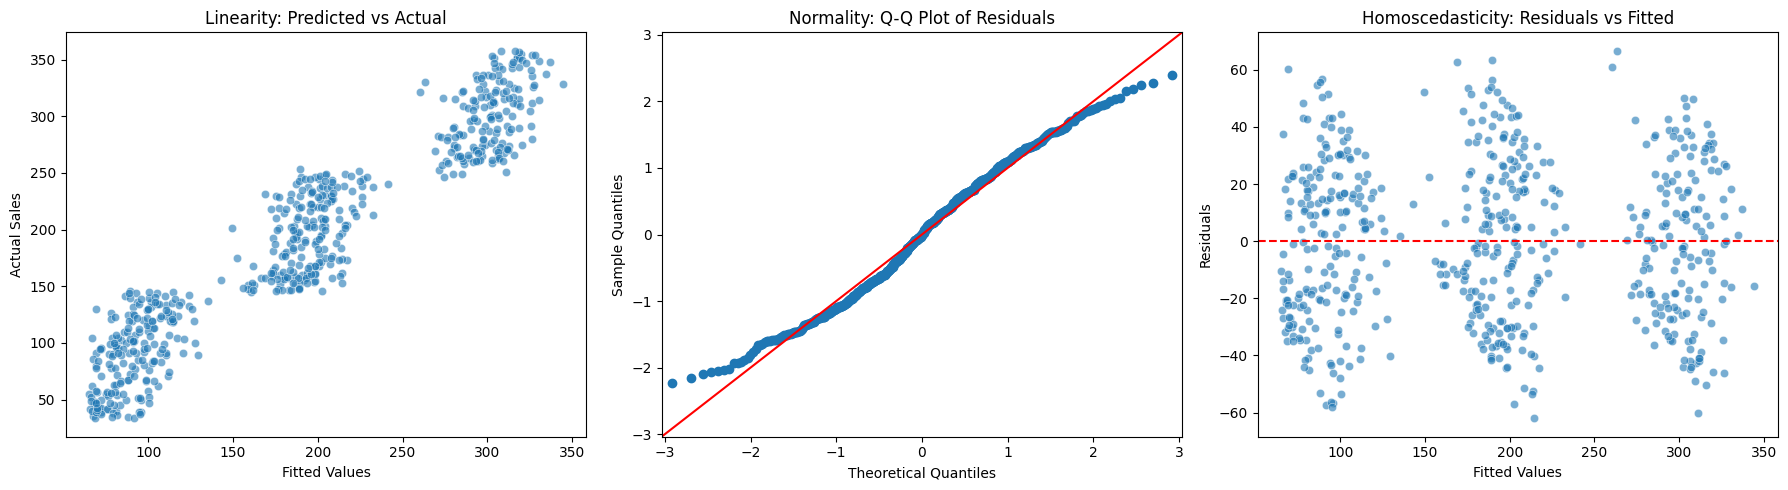

In [7]:
fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linearity: Predicted vs Actual
sns.scatterplot(x=fitted_values, y=y, ax=axes[0], alpha=0.6)
axes[0].set_title("Linearity: Predicted vs Actual")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Actual Sales")

# 2. Normality of Residuals: Q-Q Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title("Normality: Q-Q Plot of Residuals")

# 3. Homoscedasticity: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[2], alpha=0.6)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title("Homoscedasticity: Residuals vs Fitted")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Step 6: Business Interpretations & ROI Recommendation

**Statistical Insights & Variable Justification:**
* **Adjusted R-squared (0.903):** Our model explains ~90.3% of the variance in Sales. This indicates a highly robust predictive model.
* **Variable Significance (p-values):** * `TV_encoded` (p = 0.000) and `Radio` (p = 0.000) are statistically significant and are massive drivers of Sales.
    * `Social Media` (p = 0.815) is strictly greater than 0.05, meaning it is **not** statistically significant. It fails to justify its inclusion in predicting Sales and could technically be dropped from a future refined model without hurting the Adjusted R-squared.

**Coefficient Interpretations:**
* **TV (77.32):** Holding Radio and Social Media spend constant, upgrading TV ad spend by exactly one tier (e.g., moving from a "Low" budget to a "Medium" budget) is associated with an approximate increase of 77.32 units in Sales.
* **Radio (2.97):** Holding TV and Social Media spend constant, each additional unit spent on Radio advertising is associated with a 2.97 unit increase in Sales.
* **Social Media (-0.15):** Holding other factors constant, Social Media spend has virtually zero (and slightly negative) impact on Sales, though the high p-value proves this is likely due to random noise.

**Final Business Recommendation:**
Based on the regression outputs, the marketing department should **halt or heavily reduce the Social Media budget**, as it provides no statistically provable ROI. The budget should be aggressively reallocated toward **TV advertising (which offers massive categorical jumps in sales)** and **Radio advertising (which provides a reliable 2.97x continuous multiplier)**.